In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Load data
spy = yf.download("SPY", start="2014-01-01", end="2024-01-01")
spy.columns = spy.columns.droplevel(1)

# Calculate everything we need
spy['Market_Return'] = spy['Close'].pct_change()
spy['Forward_5D_Return'] = (spy['Close'].shift(-5) - spy['Close']) / spy['Close']
spy['SMA_50'] = spy['Close'].rolling(50).mean()
spy['SMA_200'] = spy['Close'].rolling(200).mean()

# FVG signals
gap_pct = (spy['Low'] - spy['High'].shift(2)) / spy['High'].shift(2)
spy['FVG_Bullish'] = (spy['Low'] > spy['High'].shift(2)) & (gap_pct > 0.002) & (spy['SMA_50'] > spy['SMA_200'])

# Strategy returns
spy['Position_FVG'] = spy['FVG_Bullish'].shift(1).rolling(5).max().fillna(0)
spy['FVG_Return'] = spy['Position_FVG'] * spy['Market_Return']
spy['BuyHold_Cumulative'] = (1 + spy['Market_Return']).cumprod()
spy['FVG_Cumulative'] = (1 + spy['FVG_Return']).cumprod()

print("Data loaded successfully")
print(f"Shape: {spy.shape}")

[*********************100%***********************]  1 of 1 completed

Data loaded successfully
Shape: (2516, 14)


In [18]:
# Sharpe Ratio Calculator
def sharpe_ratio(returns, periods=252):
    mean = returns.mean()
    std = returns.std()
    return (mean / std) * np.sqrt(periods)

sharpe_fvg = sharpe_ratio(spy['FVG_Return'].dropna())
sharpe_bh = sharpe_ratio(spy['Market_Return'].dropna())

print(f"Sharpe Ratio — FVG Strategy:  {sharpe_fvg:.3f}")
print(f"Sharpe Ratio — Buy & Hold:    {sharpe_bh:.3f}")

Sharpe Ratio — FVG Strategy:  0.320
Sharpe Ratio — Buy & Hold:    0.737


## Finding #4 — Risk-Adjusted Returns (Sharpe Ratio)
Buy & Hold Sharpe Ratio: 0.737  
FVG Strategy Sharpe Ratio: 0.320

Even on a risk-adjusted basis, passive buy and hold outperforms the 
ICT FVG strategy. The FVG strategy does not compensate investors 
adequately for the risk it takes.

In [19]:
# Maximum Drawdown Calculator
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown.min()

mdd_fvg = max_drawdown(spy['FVG_Cumulative'])
mdd_bh = max_drawdown(spy['BuyHold_Cumulative'])

print(f"Max Drawdown — FVG Strategy:  {mdd_fvg * 100:.1f}%")
print(f"Max Drawdown — Buy & Hold:    {mdd_bh * 100:.1f}%")

Max Drawdown — FVG Strategy:  -18.5%
Max Drawdown — Buy & Hold:    -33.7%


## Finding #5 — Maximum Drawdown
FVG Strategy Max Drawdown: -18.5%  
Buy & Hold Max Drawdown: -33.7%

The FVG strategy's only measurable advantage over buy and hold is 
reduced drawdown. However this protection came at the cost of 186% 
in total returns — a poor tradeoff for long term investors.

In [20]:
# Win Rate Calculator
# A trade is a win if the 5-day return was positive
trade_returns = spy[spy['FVG_Bullish'] == True]['Forward_5D_Return'].dropna()

wins = (trade_returns > 0).sum()
total = len(trade_returns)
win_rate = wins / total

print(f"Total FVG trades: {total}")
print(f"Winning trades: {wins}")
print(f"Win Rate: {win_rate * 100:.1f}%")

Total FVG trades: 301
Winning trades: 175
Win Rate: 58.1%


## Finding #6 — Win Rate
Total FVG trades: 301  
Winning trades: 175  
Win Rate: 58.1%

While the win rate appears reasonable, win rate alone is insufficient 
to evaluate a strategy. Gurus would point this out, explaining how the 
strategy works for the most part, over half the trades are profitable.
However, the size of wins versus losses determines true profitability.

In [21]:
# Win/Loss Analysis
winning_trades = trade_returns[trade_returns > 0]
losing_trades = trade_returns[trade_returns < 0]

avg_win = winning_trades.mean()
avg_loss = losing_trades.mean()
risk_reward = abs(avg_win / avg_loss)

print(f"Average Win:  {avg_win * 100:.3f}%")
print(f"Average Loss: {avg_loss * 100:.3f}%")
print(f"Risk/Reward Ratio: {risk_reward:.2f}")
print(f"Expected Value per trade: {(win_rate * avg_win + (1 - win_rate) * avg_loss) * 100:.3f}%")

Average Win:  1.090%
Average Loss: -1.356%
Risk/Reward Ratio: 0.80
Expected Value per trade: 0.066%


## Finding #7 — Risk/Reward Analysis
Average Win: 1.090% | Average Loss: -1.356%  
Risk/Reward Ratio: 0.80  
Expected Value per trade: 0.066%

When an FVG trade wins, it makes about 1.09% over 5 days.
On the contrary, when an FVG trade loses, it loses 1.356% over 5 days.
The risk/reward ratio is key; every $1 of potential loss, only $0.80 
of potential gain is made. The expected value of 0.066% per trade is positive 
but significantly below the 0.278% average 5-day return of simply holding SPY.

In [22]:
# Final Comparison Table
metrics = {
    'Metric': [
        'Total Return',
        'Sharpe Ratio', 
        'Max Drawdown',
        'Win Rate',
        'Risk/Reward Ratio',
        'Time in Market'
    ],
    'Buy & Hold': [
        '211.3%',
        '0.737',
        '-33.7%',
        'N/A',
        'N/A',
        '100%'
    ],
    'FVG Strategy': [
        '25.0%',
        '0.320',
        '-18.5%',
        '58.1%',
        '0.80',
        '12.0%'
    ]
}

df_metrics = pd.DataFrame(metrics)
print(df_metrics.to_string(index=False))

           Metric Buy & Hold FVG Strategy
     Total Return     211.3%        25.0%
     Sharpe Ratio      0.737        0.320
     Max Drawdown     -33.7%       -18.5%
         Win Rate        N/A        58.1%
Risk/Reward Ratio        N/A         0.80
   Time in Market       100%        12.0%


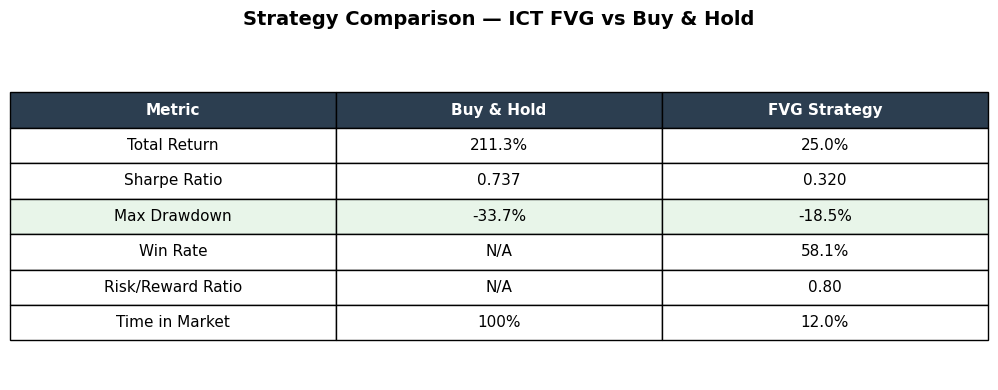

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=df_metrics.values,
    colLabels=df_metrics.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

# Header row styling
for j in range(len(df_metrics.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Highlight Max Drawdown row (FVG wins)
for j in range(len(df_metrics.columns)):
    table[3, j].set_facecolor('#e8f5e9')

ax.set_title('Strategy Comparison — ICT FVG vs Buy & Hold', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Overall Conclusion

Across every meaningful metric, passive buy and hold outperforms 
the ICT Fair Value Gap strategy on SPY from 2014-2024.

The FVG strategy's only advantage is reduced maximum drawdown (-18.5% 
vs -33.7%), which comes entirely from spending 88% of the time in cash 
— not from any genuine market insight.

A strategy that is out of the market 88% of the time will naturally 
experience smaller drawdowns. This is not an edge — it is simply 
the result of not participating.

**The data does not support the claim that ICT Fair Value Gaps 
provide a tradeable edge over passive investing on SPY.**